In [6]:
import pandas as pd
import matplotlib.pyplot as plt


In [20]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [32]:
import zipfile
import os

with zipfile.ZipFile("/content/archive.zip", 'r') as zip_ref:
    zip_ref.extractall("extracted_data")

os.listdir("extracted_data")


['lap_times.csv',
 'pit_stops.csv',
 'status.csv',
 'seasons.csv',
 'circuits.csv',
 'constructors.csv',
 'driver_standings.csv',
 'constructor_results.csv',
 'results.csv',
 'sprint_results.csv',
 'races.csv',
 'drivers.csv',
 'constructor_standings.csv',
 'qualifying.csv']

In [33]:
import pandas as pd

races = pd.read_csv("extracted_data/races.csv")
results = pd.read_csv("extracted_data/results.csv")
circuits = pd.read_csv("extracted_data/circuits.csv")

races.head()


,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


In [34]:
import pandas as pd

races = pd.read_csv('extracted_data/races.csv')
results = pd.read_csv('extracted_data/results.csv')
circuits = pd.read_csv('extracted_data/circuits.csv')
drivers = pd.read_csv('extracted_data/drivers.csv')
constructors = pd.read_csv('extracted_data/constructors.csv')
lap_times = pd.read_csv('extracted_data/lap_times.csv')
qualifying = pd.read_csv('extracted_data/qualifying.csv')
status = pd.read_csv('extracted_data/status.csv')


In [35]:
races.info()
drivers.info()
results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1125 entries, 0 to 1124
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   raceId       1125 non-null   int64 
 1   year         1125 non-null   int64 
 2   round        1125 non-null   int64 
 3   circuitId    1125 non-null   int64 
 4   name         1125 non-null   object
 5   date         1125 non-null   object
 6   time         1125 non-null   object
 7   url          1125 non-null   object
 8   fp1_date     1125 non-null   object
 9   fp1_time     1125 non-null   object
 10  fp2_date     1125 non-null   object
 11  fp2_time     1125 non-null   object
 12  fp3_date     1125 non-null   object
 13  fp3_time     1125 non-null   object
 14  quali_date   1125 non-null   object
 15  quali_time   1125 non-null   object
 16  sprint_date  1125 non-null   object
 17  sprint_time  1125 non-null   object
dtypes: int64(4), object(14)
memory usage: 158.3+ KB
<class 'pandas.core.

In [36]:
merge_df = results.merge(races, on = 'raceId').merge(drivers, on='driverId')
merge_df[['year','name','surname','position','points']].head()

,year,name,surname,position,points
0,2008,Australian Grand Prix,Hamilton,1,10.0
1,2008,Australian Grand Prix,Heidfeld,2,8.0
2,2008,Australian Grand Prix,Rosberg,3,6.0
3,2008,Australian Grand Prix,Alonso,4,5.0
4,2008,Australian Grand Prix,Kovalainen,5,4.0


RECENT = LAST 6 YEARS OF DATA (NOT INCLUDING ALL PAST YEARS
)

In [37]:
recent_races = races[races['year'].between(2019,2024)]
recent_races_id = recent_races['raceId'].unique()

In [38]:
recent_results = results[results['raceId'].isin(recent_races_id)]
recent_laps = lap_times[lap_times['raceId'].isin(recent_races_id)]
recent_qualifying = qualifying[qualifying['raceId'].isin(recent_races_id)]

In [39]:
race_per_year = recent_races.groupby('year')['raceId'].nunique()
print("Race held between 2019 to 2024 : ")
print(race_per_year)

Race held between 2019 to 2024 : 
year
2019    21
2020    17
2021    22
2022    22
2023    22
2024    24
Name: raceId, dtype: int64


In [40]:
topmost_winner = recent_results[recent_results['positionOrder'] == 1]
topmost_winner = topmost_winner.merge(drivers,  on = 'driverId')
top_winner = topmost_winner['surname'].value_counts().head(5)
print("Top 5 drivers with the most winners ")
print(top_winner)

Top 5 drivers with the most winners 
surname
Verstappen    58
Hamilton      32
Leclerc        8
Bottas         7
Pérez          6
Name: count, dtype: int64


In [41]:
topmost_winner = topmost_winner.merge(constructors,on='constructorId')
top_team = topmost_winner['name'].value_counts().head(5)
print("Top 5 most construction most winners")
print(top_team)

Top 5 most construction most winners
name
Red Bull      63
Mercedes      42
Ferrari       13
McLaren        7
AlphaTauri     1
Name: count, dtype: int64


In [42]:
top_winner_names = top_winner.index
top_win_counts = top_team.values

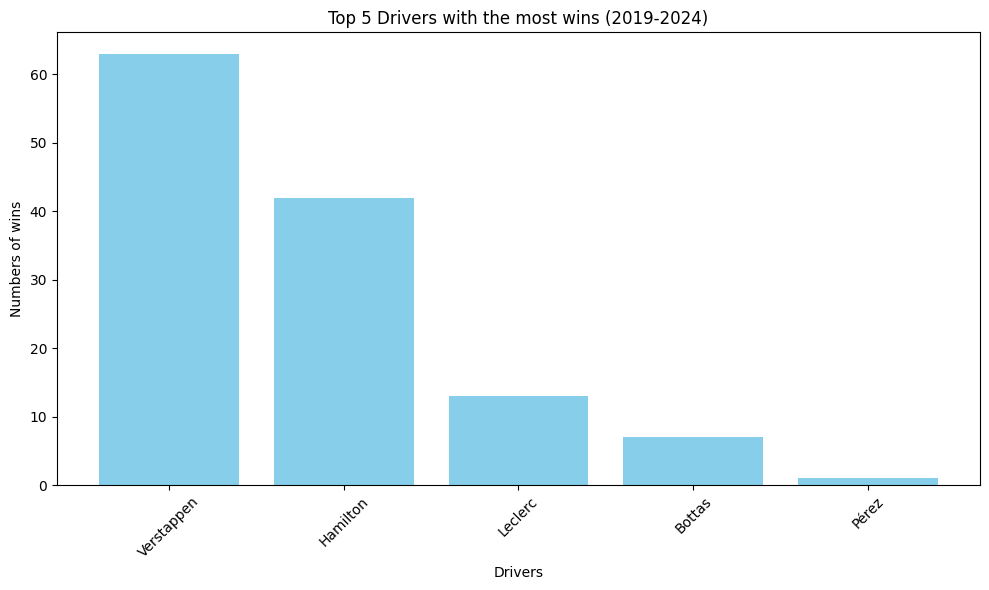

In [43]:
plt.figure(figsize=(10,6))
plt.bar(top_winner_names, top_win_counts,color="skyblue")
plt.xlabel("Drivers")
plt.ylabel("Numbers of wins")
plt.title("Top 5 Drivers with the most wins (2019-2024)")
plt.xticks(rotation = 45)
plt.tight_layout() # auto adjust the title overlapping
plt.show()

In [44]:
podiums  = recent_results[recent_results['positionOrder'] <= 3]
podium_count = podiums['driverId'].value_counts()
top5_podiums = podium_count.head(5)
print(top5_podiums)



driverId
830    90
1      68
844    43
822    37
815    31
Name: count, dtype: int64


In [45]:
top5_podiums = podium_count.head(5).reset_index()
top5_podiums.columns = ['driverId','podium_count']
top5_podiums = top5_podiums.merge(drivers,on='driverId')

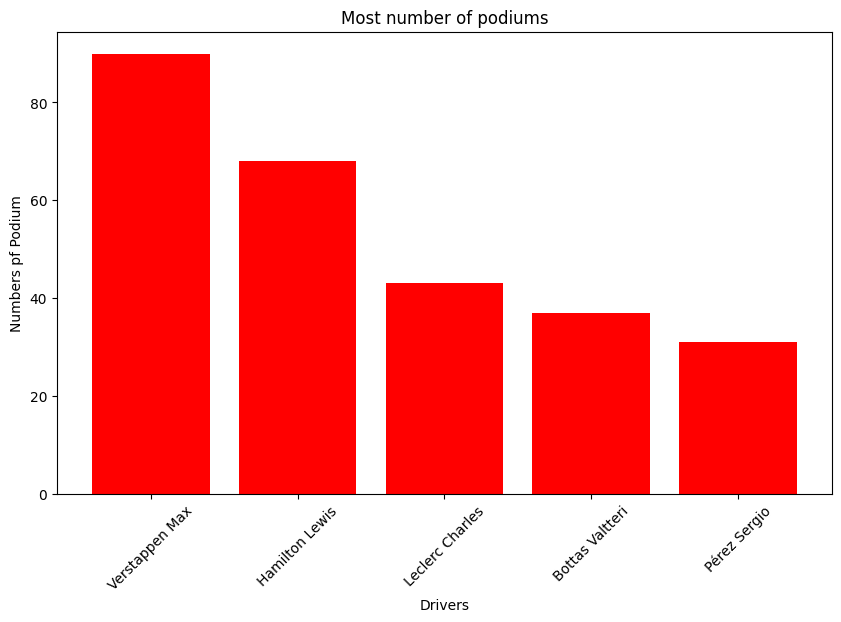

In [46]:
top5_podiums['drivers_name'] = top5_podiums['surname'] + ' ' + top5_podiums['forename']
plt.figure(figsize=(10,6))
plt.bar(top5_podiums['drivers_name'],top5_podiums['podium_count'],color='red')
plt.xlabel('Drivers')
plt.ylabel('Numbers pf Podium')
plt.title('Most number of podiums')
plt.xticks(rotation=45)
plt.tight_layout
plt.show()

In [47]:
fastest_laps = recent_results[recent_results['rank'] != '\\N']
fastest_laps = recent_results[recent_results['rank'] == '1']


driver_fastest_laps = fastest_laps['driverId'].value_counts().reset_index()
driver_fastest_laps.columns = ['driverId','fastestLapCount']
top5_fastest_laps = driver_fastest_laps.head(5)
top5_fastest_laps = top5_fastest_laps.merge(drivers,on='driverId')
top5_fastest_laps = top5_fastest_laps[['surname','forename','fastestLapCount']]
print(top5_fastest_laps)

      surname  forename  fastestLapCount
0  Verstappen       Max               29
1    Hamilton     Lewis               25
2      Norris     Lando               12
3     Leclerc   Charles               10
4      Bottas  Valtteri                9


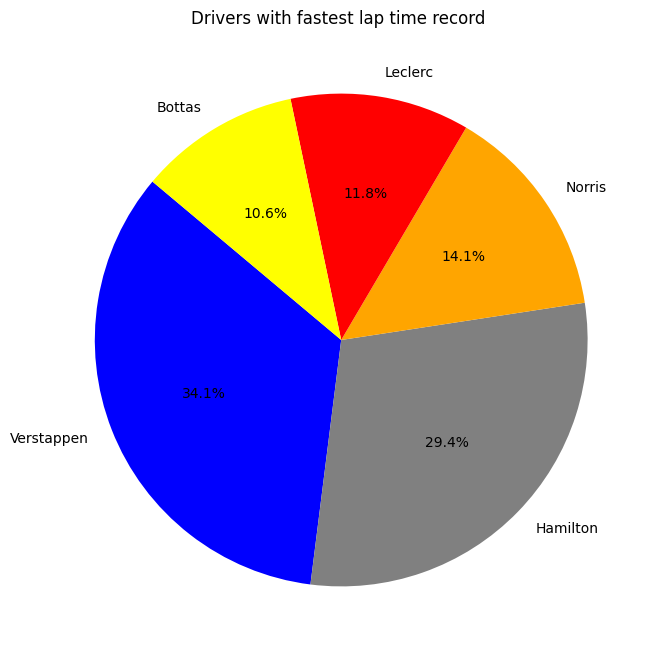

In [48]:
plt.figure(figsize=(8,8))
plt.pie(
    top5_fastest_laps['fastestLapCount'],
    labels=top5_fastest_laps['surname'],
    autopct='%1.1f%%',
    startangle=140,
    colors=['blue','grey','orange','red','yellow']
)
plt.title('Drivers with fastest lap time record ')
plt.show()

In [49]:
constructor_podium = recent_results[recent_results['positionOrder'] .isin([1,2,3])]
constructor_podium_counts = constructor_podium['constructorId'].value_counts().reset_index().head(5)
constructor_podium_counts.columns = ['constructorId','podiumCount']
top5_constructors = constructor_podium_counts.merge(constructors,on='constructorId')
top5_constructors['constructorName'] = top5_constructors['name']
print(top5_constructors)

   constructorId  podiumCount constructorRef          name nationality  \
0              9          121       red_bull      Red Bull    Austrian   
1            131          119       mercedes      Mercedes      German   
2              6           78        ferrari       Ferrari     Italian   
3              1           39        mclaren       McLaren     British   
4            117            9   aston_martin  Aston Martin     British   

                                                 url constructorName  
0       http://en.wikipedia.org/wiki/Red_Bull_Racing        Red Bull  
1  http://en.wikipedia.org/wiki/Mercedes-Benz_in_...        Mercedes  
2      http://en.wikipedia.org/wiki/Scuderia_Ferrari         Ferrari  
3               http://en.wikipedia.org/wiki/McLaren         McLaren  
4  http://en.wikipedia.org/wiki/Aston_Martin_in_F...    Aston Martin  


/tmp/ipython-input-187668890.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


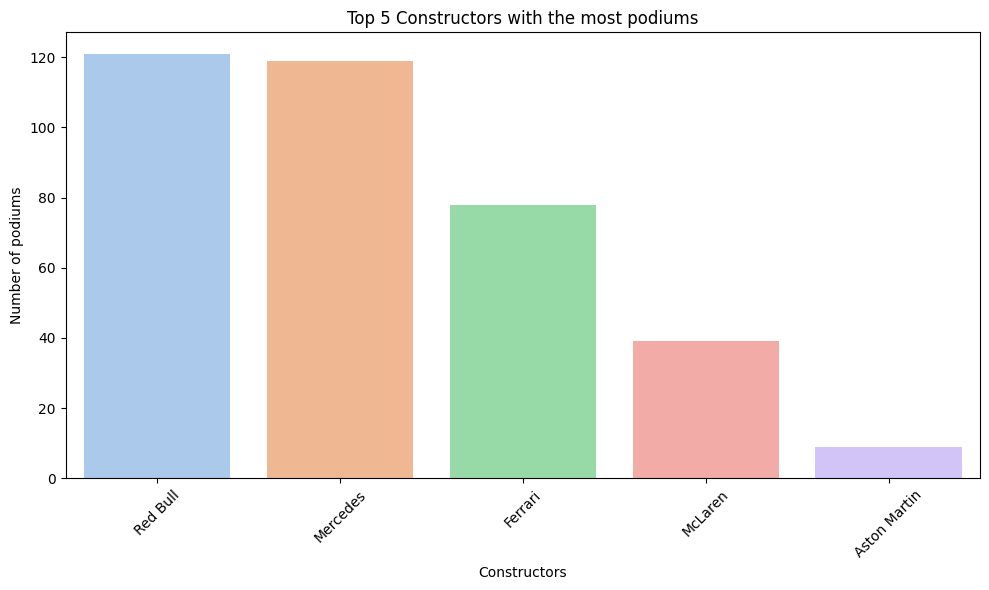

In [50]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.barplot(
    data=top5_constructors,
    x='constructorName',
    y='podiumCount',
    palette='pastel'

)
plt.title('Top 5 Constructors with the most podiums')
plt.xlabel('Constructors')
plt.ylabel('Number of podiums')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Predicting team performance data (total points per season, total wins, DNFs, trend in performance )

In [51]:
recent_races = races[races['year'] >= 2019]
recent_results = results.merge(recent_races,on='raceId')
mercedes_id = constructors[constructors['name'] == 'Mercedes']['constructorId'].values[0]
mercedes_results = recent_results[recent_results['constructorId'] == mercedes_id]

In [52]:
total_points = mercedes_results['points'].sum()
total_dnfs = mercedes_results[mercedes_results['statusId'] != 1].shape[0]
avg_points_per_race = total_points / 5

In [53]:
print("Mercedes Performance Summary")
print(f"Total points: {total_points}")
print(f"Total DNFs : {total_dnfs}")
print(f"Avg points per races : {avg_points_per_race}")

Mercedes Performance Summary
Total points: 3218.5
Total DNFs : 27
Avg points per races : 643.7


In [54]:
recent_races = races[races['year'] >= 2019]
recent_results = results.merge(recent_races,on='raceId')


In [55]:
total_points = recent_results.groupby('constructorId')['points'].sum().reset_index()
total_points.columns = ['constructorId','total_points']
print(total_points.columns)

Index(['constructorId', 'total_points'], dtype='object')


In [56]:
wins = recent_results[recent_results['positionOrder'] == 1]
total_wins = wins.groupby('constructorId')['positionOrder'].count().reset_index()
total_wins.columns = ['constructorId','total_wins']

In [57]:
dnfs = recent_results[recent_results['statusId'] !=1]
total_dnfs = dnfs.groupby('constructorId')['statusId'].count().reset_index()
total_dnfs.columns = ['constructorId','total_dnfs']

In [58]:
constructor_stats = total_points.merge(total_wins, on='constructorId', how='left')
constructor_stats = constructor_stats.merge(total_dnfs, on='constructorId', how='left')
print(constructors.columns)



Index(['constructorId', 'constructorRef', 'name', 'nationality', 'url'], dtype='object')


In [59]:
constructor_stats = constructor_stats.merge(constructors[['constructorId', 'constructorRef']], on='constructorId')
constructor_stats.rename(columns={'constructorRef':'name'},inplace=True)


In [60]:
constructor_stats.fillna(0, inplace=True)
constructor_stats['avg_points_per_race'] = constructor_stats['total_points'] / 5
constructor_stats.sort_values(by='total_points', ascending=False, inplace=True)

print(constructor_stats[['name', 'total_points', 'total_wins', 'total_dnfs', 'avg_points_per_race']].head(5))


        name  total_points  total_wins  total_dnfs  avg_points_per_race
5   red_bull        3365.5        63.0          43                673.1
9   mercedes        3218.5        42.0          27                643.7
4    ferrari        2434.5        13.0          55                486.9
0    mclaren        1646.0         7.0          77                329.2
13    alpine         498.0         1.0          81                 99.6


Ranking which team will be best for the best for max to join in 2027
i create a custom score using :
1.total points (weight: 50%)
2.total wins (weight : 30%)
3.low DNFs (weight : 20%)


In [61]:
constructor_stats['norm_points'] = constructor_stats['total_points']/constructor_stats['total_points'].max()
constructor_stats['norm_wins'] = constructor_stats['total_points']/constructor_stats['total_points'].max()
constructor_stats['norm_dnfs'] = constructor_stats['total_points']/constructor_stats['total_points'].max()


In [62]:
constructor_stats['team_score'] = (
    constructor_stats['norm_points'] * 0.5 +
    constructor_stats['norm_wins'] * 0.3 +
    (1 - constructor_stats['norm_dnfs']) * 0.2
)

In [63]:
constructor_stats.sort_values(by='team_score',ascending=False,inplace=True)
print(constructor_stats[['name','team_score']].head(5))

        name  team_score
5   red_bull    0.800000
9   mercedes    0.773793
4    ferrari    0.634022
0    mclaren    0.493448
13    alpine    0.288783


now i will find which teammate will best for the max but what make it best -

1.   high podium not always 1
2.   good finishing records few dnfs
3.   consistent performance



In [64]:
podiums = recent_results[(recent_results['positionOrder'] <= 3) & (recent_results['driverId'] != 830)]
podium_count = podiums['driverId'].value_counts().reset_index()
podium_count.columns = ['driverId','podium_count']


In [65]:
podium_count = podium_count.merge(drivers[['driverId','surname']],on = 'driverId')
print(podium_count.head())

   driverId  podium_count   surname
0         1            68  Hamilton
1       844            43   Leclerc
2       822            37    Bottas
3       815            31     Pérez
4       832            27     Sainz


In [66]:
non_max_results = recent_results[recent_results['driverId'] != 830]
podium = non_max_results[non_max_results['positionOrder'] <=3]
podium_count = podiums['driverId'].value_counts().reset_index()
podium_count.columns = ['driverId','podium_count']
print(podium_count)

    driverId  podium_count
0          1            68
1        844            43
2        822            37
3        815            31
4        832            27
5        846            26
6        847            15
7         20            11
8        857            10
9          4             9
10       842             5
11       839             4
12       817             3
13       840             2
14       848             2
15       826             1


In [67]:
driver_points = non_max_results.groupby('driverId')['points'].sum().reset_index()
driver_points.columns = ['driverId','total_points']

In [68]:
dnfs = non_max_results[non_max_results['positionOrder'] !=1]
driver_dnfs = dnfs.groupby('driverId')['statusId'].count().reset_index()
driver_dnfs.columns = ['driverId','total_dnfs']

In [69]:
driver_stats = podium_count.merge(driver_points, on='driverId',how='outer')
driver_stats = driver_stats.merge(driver_dnfs, on='driverId',how='outer')
driver_stats.fillna(0,inplace=True)

In [70]:
driver_stats['norm_podium'] = driver_stats['podium_count']/driver_stats['podium_count'].max()
driver_stats['norm_points'] = driver_stats['total_points']/driver_stats['total_points'].max()
driver_stats['norm_dnfs'] = driver_stats['total_dnfs']/driver_stats['total_dnfs'].max()

In [71]:
driver_stats['driver_score'] = (
    driver_stats['norm_podium']*0.4+
    driver_stats['norm_points']*0.4+
    driver_stats['norm_dnfs']*0.2
  )

In [72]:
driver_stats = driver_stats.merge(drivers[['driverId', 'surname']], on='driverId')
driver_stats.sort_values(by='driver_score', ascending=False, inplace=True)

print(driver_stats[['surname', 'driver_score', 'podium_count', 'total_points', 'total_dnfs']].head(5))


     surname  driver_score  podium_count  total_points  total_dnfs
0   Hamilton      0.949606          68.0        1802.5          95
17   Leclerc      0.735732          43.0        1324.0         120
7      Pérez      0.605671          31.0        1056.0         120
9     Bottas      0.591277          37.0         825.0         121
12     Sainz      0.581651          27.0        1032.5         123


In [73]:
top_team = constructor_stats[['constructorId','name','team_score']].sort_values(by='team_score',ascending=False).head(5)
print(top_team)

    constructorId      name  team_score
5               9  red_bull    0.800000
9             131  mercedes    0.773793
4               6   ferrari    0.634022
0               1   mclaren    0.493448
13            214    alpine    0.288783


In [74]:
top_teammate = driver_stats[['driverId','surname','driver_score']].sort_values(by='driver_score',ascending=False).head(5)
print(top_teammate)

    driverId   surname  driver_score
0          1  Hamilton      0.949606
17       844   Leclerc      0.735732
7        815     Pérez      0.605671
9        822    Bottas      0.591277
12       832     Sainz      0.581651


now i will find the driver who is most consistent in scoring points


In [75]:
driver_team_freq = non_max_results.groupby(['driverId','constructorId']).size().reset_index(name='race_count')
main_driver_team = driver_team_freq.sort_values(by='race_count',ascending=False).drop_duplicates('driverId')
main_driver_team = main_driver_team.merge(constructors[['constructorId','constructorRef']],on='constructorId')
main_driver_team.rename(columns={'constructorRef':'team_name'},inplace=True)
top_driver_teams = top_teammate.merge(main_driver_team[['driverId','team_name']],on='driverId',how='left')
print(top_driver_teams[['surname','team_name']])

    surname team_name
0  Hamilton  mercedes
1   Leclerc   ferrari
2     Pérez  red_bull
3    Bottas  mercedes
4     Sainz   ferrari


In [76]:
import itertools

combinations = list(itertools.product(top_team.itertuples(index=False, name=None),top_teammate.itertuples(index=False, name=None)))

combo_list = []

for team, driver in combinations:
    team_name = team[1]
    team_score = team[2]
    teammate = driver[1]
    driver_score = driver[2]

    combo_score = team_score * 0.6 + driver_score * 0.4

    combo_list.append({
        'team_name': team_name,
        'teammate': teammate,
        'team_score': round(team_score, 3),
        'driver_score': round(driver_score, 3),
        'combo_score': round(combo_score, 3)
    })


In [77]:
combo_df = pd.DataFrame(combo_list)
combo_df.sort_values(by='combo_score', ascending=False, inplace=True)
print(combo_df.head(5))


   team_name  teammate  team_score  driver_score  combo_score
0   red_bull  Hamilton       0.800         0.950        0.860
5   mercedes  Hamilton       0.774         0.950        0.844
1   red_bull   Leclerc       0.800         0.736        0.774
10   ferrari  Hamilton       0.634         0.950        0.760
6   mercedes   Leclerc       0.774         0.736        0.759


so upper results show that the best combination for max is hamilton in redbull

/tmp/ipython-input-3896864320.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=combo_df,x='combo_score', y=combo_df['team_name'] + " + " + combo_df['teammate'], palette='viridis')


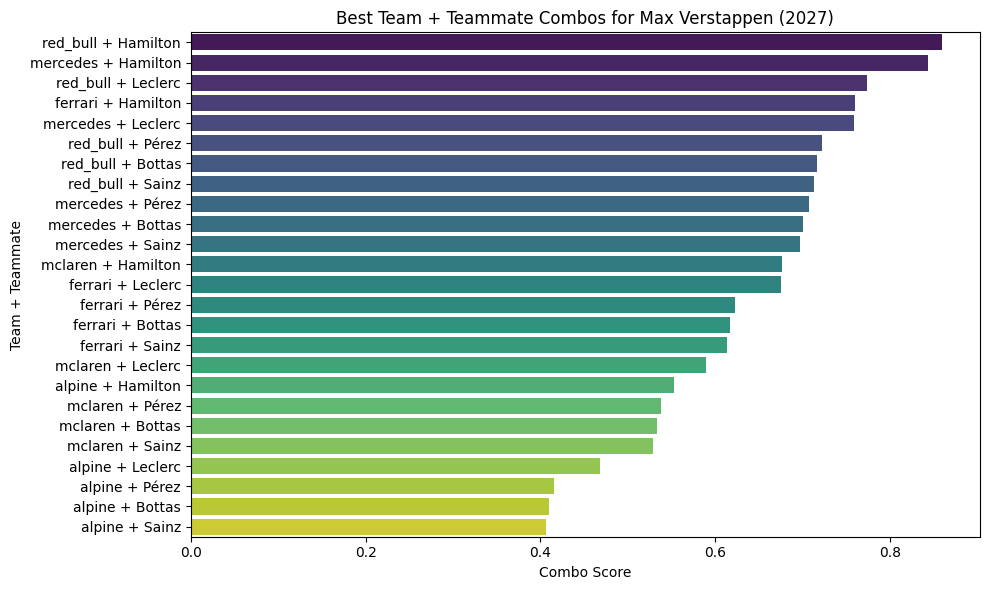

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(data=combo_df,x='combo_score', y=combo_df['team_name'] + " + " + combo_df['teammate'], palette='viridis')
plt.xlabel("Combo Score")
plt.ylabel("Team + Teammate")
plt.title("Best Team + Teammate Combos for Max Verstappen (2027)")
plt.tight_layout()
plt.show()


In [79]:
combo_df.to_csv("max_verstappen_2027_team_prediction.csv", index=False)


In [80]:
from google.colab import files
files.download("max_verstappen_2027_team_prediction.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>